In [1]:
import torchklip as tkl

import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch

Logging initialized. Log file: /Users/chialinko/Workshop/Repo/torchKLIP/logs/torchklip_20250521_021809.log


## 0. Download the Beta Pictoris Dataset

> If you already have the data, you can skip this step.

This step will: 
1. Creates a directory `../data/` (you can change this path if needed)
2. Downloads  two files from the `naco_betapic_preproc.npz` from [VIP_extras GitHub repository](https://github.com/vortex-exoplanet/VIP_extras/tree/master/datasets)
    - `naco_betapic_cube.fits`: the preprocessed image cube
    - `naco_betapic_pa.fits`: the corresponding parallactic angles
3. Saves the file in the `../data/` directory.
4. Verifies that the file was successfully downloaded and saved.

Once the file is downloaded, you're ready to move on to the analysis.

In [2]:
# Define the directory and file paths
data_dir = Path("../data")

# 1. Create the ../data directory if it doesn't exist
data_dir.mkdir(parents=True, exist_ok=True)

# 2. Define file names and URLs
files_to_download = {
    "naco_betapic_cube_cen.fits": "https://github.com/vortex-exoplanet/VIP_extras/raw/master/datasets/naco_betapic_cube_cen.fits",
    "naco_betapic_derot_angles.fits": "https://github.com/vortex-exoplanet/VIP_extras/raw/master/datasets/naco_betapic_derot_angles.fits",
}

# 3. Download and verify each file
for file_name, url in files_to_download.items():
    file_path = data_dir / file_name
    os.system(f"curl -o {file_path} -L {url}")
    
    assert os.path.exists(file_path), f"Download failed: {file_path} not found."
    print(f"File downloaded successfully and saved to: {file_path}")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 2435k  100 2435k    0     0  1014k      0  0:00:02  0:00:02 --:--:-- 1566k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

File downloaded successfully and saved to: ../data/naco_betapic_cube_cen.fits


  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

File downloaded successfully and saved to: ../data/naco_betapic_derot_angles.fits


100  5760  100  5760    0     0   9465      0 --:--:-- --:--:-- --:--:-- 28656


## 1. Load the Beta Pictoris Dataset

Now that we have the dataset, let's load it into memory.

- We work with two separate `.fits` files:
    1. `naco_betapic_cube_cen.fits`: a data cube (a stack of 2D images over time)
    2. `naco_betapic_derot_angles.fits`: the corresponding parallactic angles, used for angular differential imaging (ADI) processing
- We use the `load_data` function from `torchKLIP` to read these components. 
- These will serve as inputs for PSF subtraction in the subsequent steps.

In [3]:
# Define the path to the data file
folder_path = Path("../data")
fn_cube = folder_path / "naco_betapic_cube_cen.fits"
fn_angle = folder_path / "naco_betapic_derot_angles.fits"

# Load the data
cube = tkl.load_data(fn_cube)
angles = tkl.load_data(fn_angle)
# Print their shapes to confirm successful loading
print("Cube Data Shape:", cube.shape)
print("Angles Data Shape:", angles.shape)

Successfully loaded .fits file: ../data/naco_betapic_cube_cen.fits
HDU 0: shape (61, 101, 101)
Successfully loaded .fits file: ../data/naco_betapic_derot_angles.fits
HDU 0: shape (61,)


Cube Data Shape: (61, 101, 101)
Angles Data Shape: (61,)


### Visualize the First Frame of the Dataset

To get a sense of what the original data looks like, we visualize the first frame of the data cube:
- The star is centered at coordinates (50, 50).
- We apply a log scale to enhance faint structures.
- A circle marks the inner working angle (IWA).
- A scalebar shows the angular and physical scale.

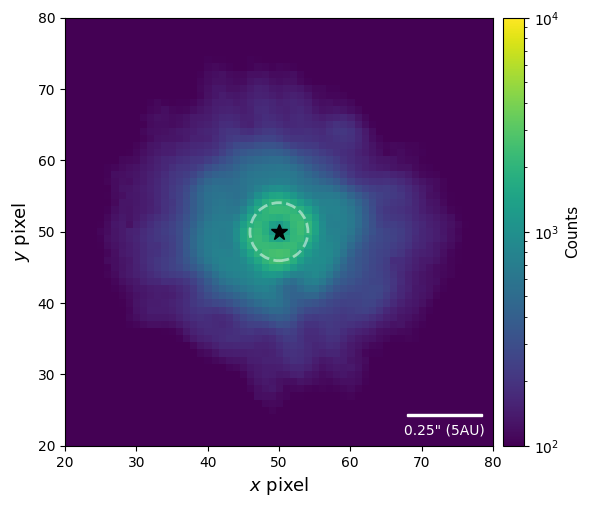

In [4]:
### Visualizing the First Frame of the Dataset
fig, ax = tkl.plot_image(cube[0], 
                        center_coords=(50, 50), 
                        vmin = 1e2, vmax = 1e4,                   # Intensity range for display
                        log_scale=True,                           # Log scaling for contrast
                        xlim_half_range = 30, ylim_half_range=30, # Zoom into a 60x60 region
                        show_center = True,                       # Mark the center of the frame
                        iwa_radius = 4.065,                       # Inner working angle in pixels
                        scalebar_length = 10.48,                  # Length of scalebar in pixels
                        scalebar_label ='0.25" (5AU)',            # Scalebar label
                        # output_filename = './betaPic_init.png'  # Optional: Save the figure
                        )
plt.show()

## 2. Preprocessing the Data

This step prepares the data for PSF subtraction using the KLIP algorithm:
- The image cube is wrapped in a `DataTensor` object, with the center of the target set to coordinates `(50, 50)`.
- An Inner Working Angle (IWA) of 4 pixels is applied using the `mask_circular_()` method.
- Pixels within the IWA are masked (set to `NaN`) to exclude the innermost region from the analysis, where PSF subtraction is typically unreliable.

The `DataTensor` class handles these preprocessing steps to make sure the data is properly formatted and masked for subsequent PSF modeling.

In [5]:
# Preprocess the data
tensordata = tkl.DataTensor(cube, center = [50, 50], IWA=4)  
tensordata.mask_circular_();

### Visualize the First Frame of the Preprocessed Image

This visualization helps verify that the centering and masking steps were applied correctly before proceeding to PSF subtraction.

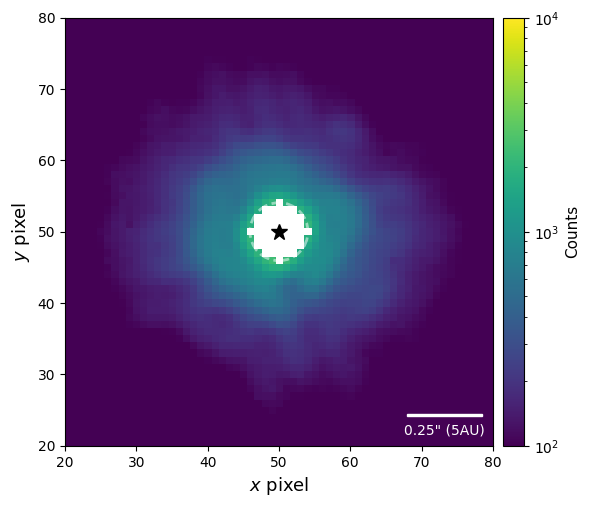

In [6]:

fig, ax = tkl.plot_image(tensordata[0], 
                        center_coords=(50, 50), 
                        vmin = 1e2, vmax = 1e4,                   # Intensity range for display
                        log_scale=True,                           # Log scaling for contrast
                        xlim_half_range = 30, ylim_half_range=30, # Zoom into a 60x60 region
                        show_center = True,                       # Mark the center of the frame
                        iwa_radius = 4.065,                       # Inner working angle in pixels
                        scalebar_length = 10.48,                  # Length of scalebar in pixels
                        scalebar_label ='0.25" (5AU)',            # Scalebar label
                        # output_filename = './betaPic_init.png'  # Optional: Save the figure
                        )
plt.show()

## 3. Running the KLIP Algorithm

In this cell, we run the KLIP algorithm to perform high-contrast imaging analysis:

- **Device Setup:** We check for GPU availability and set the computation device to `"cuda"` if available, otherwise fallback to `"cpu"`.
- **Algorithm Initialization:** A TorchKLIP instance is created using the preprocessed `DataTensor`, the parallactic angles, and the selected device.
- **Algorithm Execution:** The `klip_and_derotate` function is executed with specific parameters:
  - `mode="adi"` to specify Angular Differential Imaging (currently the only supported mode).
  - `K_klip=[10, 20]` to generate outputs using two different numbers of KL modes.
  - `use_svd=True` to perform KL decomposition using Singular Value Decomposition.
- **Performance Monitoring**: Time and memory usage metrics can be printed using `torchklip.perfmon.print_metrics()` to assess the computational cost of the KLIP processing steps.

In [7]:
# Run the KLIP algorithm
device = "cuda" if torch.cuda.is_available() else "cpu"
torchklip = tkl.TorchKLIP(tensordata, angles, device=device, collect_metrics=True)
result = torchklip.klip_and_derotate(mode="adi", K_klip=[10, 20], method="svd")
torchklip.perfmon.print_metrics()

Applying circular mask with IWA=4, OWA=None
Running KLIP with K=[10, 20], method=svd, statistic=mean
Starting compute_residuals
Computing KL basis with method='svd', K_max=20
Finished compute_residuals
 Performance Metrics
-- Memory Usage --
System Total Memory: 16.00 GB
System Available Memory: 5.82 GB
System Memory Used: 63.7%
Process RSS Memory: 305.47 MB
Process Virtual Memory: 33.16 GB
------------------------------------
-- Execution Times --
Total Execution Time: 136.97 ms
- Psfsub: 113.20 ms (82.6% of total)
- Derotate: 19.53 ms (14.3% of total)
- Combine: 4.22 ms (3.1% of total)


### Visualize the KLIP Result
This step displays the output of the KLIP algorithm for visual inspection:
- Shows the first result frame generated
- Uses a linear intensity scale with `vmin=-6` and `vmax=16` to enhance visibility of residual features

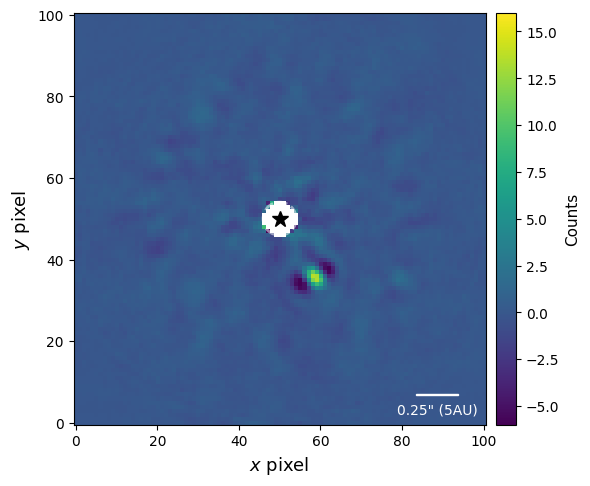

In [8]:
fig, ax = tkl.plot_image(result[0], vmin=-6, vmax=16,
                         center_coords=(50, 50), 
                         show_center = True,                       # Mark the center of the frame
                         iwa_radius = 4.065,                       # Inner working angle in pixels
                         scalebar_length = 10.48,                  # Length of scalebar in pixels
                         scalebar_label ='0.25" (5AU)',            # Scalebar label
                         )

## 4. Calculate the Signal-to-Noise Ratio (SNR)

This step computes the **Signal-to-Noise Ratio (SNR)** at the known planet location to quantify detection significance:

- The planet is located at pixel coordinates `(59, 36)`.
- An aperture with a full width at half maximum (FWHM) of 4 pixels is used to estimate the signal.
- `exclude_planet = False` means the planet's signal will not be masked during noise estimation.
- `exclude_nearest = 2` excludes pixels within 2 FWHM of the planet location from the noise annulus to avoid contamination.

The `compute_snr` function returns the SNR value at the specified location, helping assess the confidence of the planet detection in the KLIP-processed image.

In [9]:
# Calcuate SNR
planet_x, planet_y = 59, 36  # location of the planet (pixels)
fwhm = 4                     # aperture diameter in pixels
exclude_planet = False
exclude_nearest = 2

snr_value = tkl.compute_snr(result, planet_x, planet_y, fwhm,
                            exclude_planet=exclude_planet,
                            exclude_nearest=exclude_nearest)

Frame 0: SNR = 28.43
Frame 1: SNR = 22.57
 Signal-to-Noise Ratio (SNR) Summary
Min SNR: 22.57 at Frame 1
Max SNR: 28.43 at Frame 0
------------------------------------

